In [12]:
import sys, platform, warnings
from pathlib import Path
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

# 3D / point-cloud libs
import open3d as o3d
try:
    import trimesh  # optional fallback loader; not required for every workflow
    HAS_TRIMESH = True
except Exception:
    HAS_TRIMESH = False
    warnings.warn(
        "trimesh not found; install with `pip install trimesh` if you need a fallback OFF loader."
    )

# ✅ Reproducibility (optional)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 🖥️ Environment summary
print("Python          :",
      sys.version.split()[0], f"({platform.system()} {platform.release()})")
print("PyTorch         :", torch.__version__)
print("Open3D          :", o3d.__version__)
print("trimesh         :", "installed" if HAS_TRIMESH else "not installed")

# ⚙️ Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("\nCUDA available  : True")
    print("Using device    :", device)
    print("GPU count       :", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"  • GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    device = torch.device("cpu")
    print("\nCUDA available  : False")
    print("Using device    :", device)

Python          : 3.10.18 (Windows 10)
PyTorch         : 2.8.0+cu126
Open3D          : 0.19.0
trimesh         : installed

CUDA available  : True
Using device    : cuda
GPU count       : 1
  • GPU 0: Quadro T1000


In [13]:
from pathlib import Path

# 👇 Change this to your ModelNet40 root
ROOT = Path(
    r"C:\Users\jkarafotis\Desktop\MyDev\Projects\DeepLearning\data\ModelNet40")

POS_CLASS = "airplane"  # positive class label
N_POINTS = 1024  # points per shape (try 512–2048)
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-3
NUM_WORKERS = 0  # keep 0 on Windows/Jupyter
CACHE_IN_RAM = False  # True speeds up (uses more RAM)
SAMPLE_METHOD = "uniform"  # "uniform" or "poisson"

In [14]:
import numpy as np
import open3d as o3d


def load_off_robust(path: Path) -> o3d.geometry.TriangleMesh:
    """Parse OFF with tolerant header + polygon faces -> Open3D TriangleMesh."""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        raw = [
            ln.strip() for ln in f
            if ln.strip() and not ln.lstrip().startswith("#")
        ]

    if not raw or not raw[0].startswith("OFF"):
        raise ValueError(f"Not a valid OFF file: {path}")

    hdr = raw[0]
    i = 1
    tokens = hdr[3:].strip().split()
    if len(tokens) >= 3:
        n_verts, n_faces, _ = map(int, tokens[:3])
    else:
        n_verts, n_faces, _ = map(int, raw[i].split()[:3])
        i += 1

    verts = []
    for _ in range(n_verts):
        x, y, z = map(float, raw[i].split()[:3])
        verts.append([x, y, z])
        i += 1
    verts = np.asarray(verts, dtype=np.float32)

    tris = []
    for _ in range(n_faces):
        parts = raw[i].split()
        i += 1
        k = int(parts[0])
        idxs = list(map(int, parts[1:1 + k]))
        if k >= 3:
            v0 = idxs[0]
            for j in range(1, k - 1):
                tris.append([v0, idxs[j], idxs[j + 1]])
    if not tris:
        raise ValueError(f"No triangles parsed: {path}")

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(verts.astype(np.float64))
    mesh.triangles = o3d.utility.Vector3iVector(
        np.asarray(tris, dtype=np.int32))
    return mesh


def sample_points_from_off(path: Path,
                           n_points=1024,
                           method="uniform") -> np.ndarray:
    mesh = load_off_robust(path)
    if method == "poisson":
        pcd = mesh.sample_points_poisson_disk(number_of_points=n_points,
                                              init_factor=5,
                                              use_triangle_normal=True)
    else:
        pcd = mesh.sample_points_uniformly(number_of_points=n_points)
    pts = np.asarray(pcd.points, dtype=np.float32)
    if pts.shape[0] == 0:
        raise ValueError(f"Sampling produced zero points: {path}")
    return pts


def normalize_point_cloud(pts: np.ndarray) -> np.ndarray:
    centroid = pts.mean(axis=0, keepdims=True)
    pts = pts - centroid
    scale = np.max(np.linalg.norm(pts, axis=1))
    if scale > 0:
        pts = pts / scale
    return pts.astype(np.float32)



In [15]:
import random
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader

class ModelNet40AirplaneBinary(Dataset):
    """label=1 → airplane, label=0 → any other category.
       Built-in downsampling:
         - max_items: cap total samples
         - fraction: keep a random fraction (0<frac<=1)
         - balance_pos_neg: tuple (pos_keep, neg_keep) to balance classes
    """
    def __init__(self,
                 root: Path,
                 split: str = "train",
                 n_points: int = 1024,
                 cache: bool = False,
                 method: str = "uniform",
                 max_items: int | None = None,
                 fraction: float | None = None,
                 balance_pos_neg: tuple[int, int] | None = None):
        self.root = root
        self.split = split
        self.n_points = n_points
        self.cache = cache
        self.method = method
        self.items = []
        self._cache = {}

        # Build (path, label) list
        categories = sorted([d.name for d in root.iterdir() if d.is_dir()])
        for c in categories:
            split_dir = root / c / split
            if not split_dir.exists():
                continue
            for off in split_dir.glob("*.off"):
                label = 1 if c == POS_CLASS else 0
                self.items.append((off, label))

        if not self.items:
            raise RuntimeError(f"No .off files found under {root} for split={split}")

        # ----- Downsampling options -----
        if balance_pos_neg is not None:
            pos_keep, neg_keep = balance_pos_neg
            pos = [(p, y) for (p, y) in self.items if y == 1]
            neg = [(p, y) for (p, y) in self.items if y == 0]
            pos = random.sample(pos, min(pos_keep, len(pos)))
            neg = random.sample(neg, min(neg_keep, len(neg)))
            self.items = pos + neg
            random.shuffle(self.items)
        elif fraction is not None:
            k = max(1, int(len(self.items) * float(fraction)))
            self.items = random.sample(self.items, k)
        elif max_items is not None and len(self.items) > max_items:
            self.items = random.sample(self.items, max_items)
        # --------------------------------

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        max_retries, tries = 6, 0
        while tries < max_retries:
            off_path, label = self.items[idx]
            try:
                if self.cache and off_path in self._cache:
                    pts = self._cache[off_path]
                else:
                    pts = sample_points_from_off(off_path, self.n_points, self.method)
                    pts = normalize_point_cloud(pts)
                    if self.cache:
                        self._cache[off_path] = pts
                return torch.from_numpy(pts), torch.tensor(label, dtype=torch.long)
            except Exception as e:
                if tries == 0:
                    print(f"[warn] Skipping bad OFF: {off_path.name} ({e})")
                tries += 1
                idx = random.randrange(0, len(self.items))
        raise RuntimeError("Too many unreadable meshes in a row; check dataset.")

def collate_fn(batch):
    pts_list, labels = zip(*batch)          # list[(N,3)], list[()]
    pts = torch.stack(pts_list, dim=0)      # (B, N, 3)
    labels = torch.stack(labels, dim=0)     # (B,)
    return pts, labels

# ---- Create datasets with built-in downsizing knobs ----
train_ds = ModelNet40AirplaneBinary(
    ROOT, split="train",
    n_points=N_POINTS, cache=CACHE_IN_RAM, method=SAMPLE_METHOD,
    # choose ONE of the following three lines (or leave all None for full data):
    # max_items=600,
    # fraction=0.3,                 # keep 30% randomly
    balance_pos_neg=(300, 300), # keep 300 airplanes + 300 non-airplanes
)

test_ds = ModelNet40AirplaneBinary(
    ROOT,
    split="test",
    n_points=N_POINTS,
    cache=CACHE_IN_RAM,
    method=SAMPLE_METHOD,
    #max_items=200,                # smaller test set for quick runs
    balance_pos_neg=(200, 200)
)

train_loader = DataLoader(train_ds,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=NUM_WORKERS,
                          collate_fn=collate_fn)
test_loader = DataLoader(test_ds,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=NUM_WORKERS,
                         collate_fn=collate_fn)

print(f"Training data Length: {len(train_ds)}\nTest Data Length: {len(test_ds)}")


Training data Length: 600
Test Data Length: 300


In [16]:
import torch.nn as nn
import torch


class SimplePointNet(nn.Module):
    """
    Per-point MLP (1D convs) → symmetric aggregation (max) → MLP classifier.
    Input:  (B, N, 3)
    Output: (B, 2) logits
    """

    def __init__(self, num_classes=2):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv1d(3, 64, 1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 128, 1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, 1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, 3, N)
        x = self.feat(x)  # (B, 256, N)
        x = torch.max(x, dim=2).values  # (B, 256)
        return self.classifier(x)  # (B, 2)


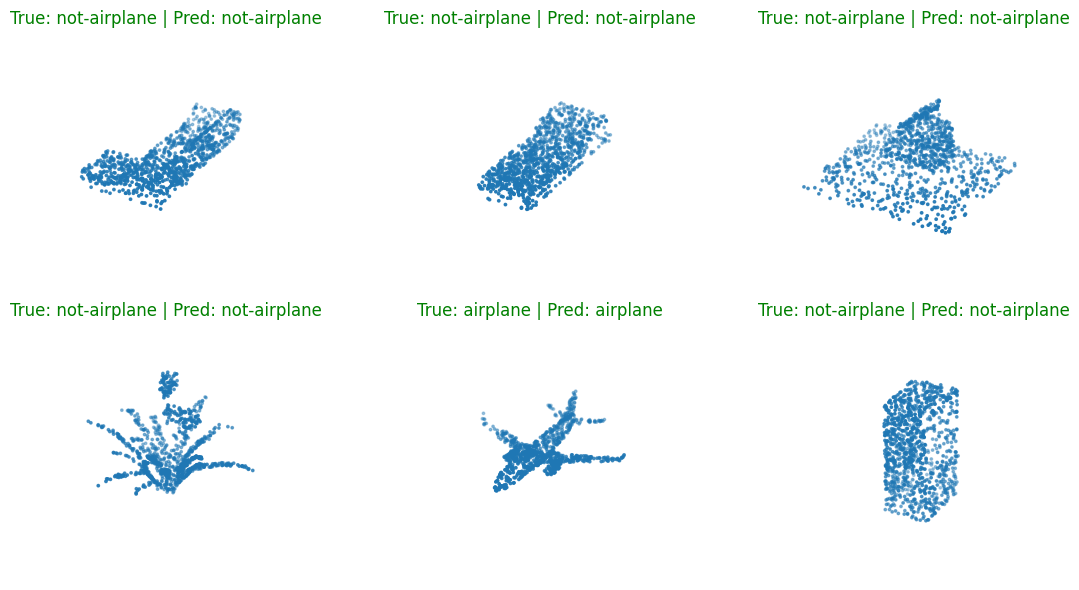

In [17]:
# 👁️ Visualize Sample Point-Cloud Predictions (2×3 grid) — loads model from path

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---- load trained model from disk ----
LOAD_PATH = Path(r"C:\Users\jkarafotis\Desktop\MyDev\Projects\DeepLearning\Models\airplane_binary_pointnet.pth")

model = SimplePointNet(num_classes=2).to(device)
state = torch.load(LOAD_PATH, map_location=device)
# handle both raw state_dict or checkpoint dicts
if isinstance(state, dict) and "model_state_dict" in state:
    model.load_state_dict(state["model_state_dict"])
else:
    model.load_state_dict(state)
model.eval()

# Optional: map numeric labels to names for nicer titles
CLASS_NAMES = {0: "not-airplane", 1: "airplane"}

def plot_point_cloud(ax, pts_np, title="", s=3):
    """
    pts_np: (N, 3) numpy array
    """
    x, y, z = pts_np[:, 0], pts_np[:, 1], pts_np[:, 2]
    ax.scatter(x, y, z, s=s)  # keep it simple
    ax.set_title(title, pad=6)
    ax.set_axis_off()

    # make aspect equal
    max_range = (np.max(pts_np, axis=0) - np.min(pts_np, axis=0)).max()
    mid = np.mean(pts_np, axis=0)
    for dim, m in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], mid):
        dim(m - max_range/2, m + max_range/2)

# ---- run one batch through the model ----
pts_batch, labels = next(iter(test_loader))           # pts: (B, N, 3), labels: (B,)
pts_batch, labels = pts_batch.to(device), labels.to(device)

with torch.no_grad():
    logits = model(pts_batch)
    preds = logits.argmax(1)

# ---- pick 6 random examples to visualize ----
num_show = 6
idxs = [random.randrange(0, pts_batch.size(0)) for _ in range(num_show)]

fig = plt.figure(figsize=(12, 6))
for i, idx in enumerate(idxs, 1):
    ax = fig.add_subplot(2, 3, i, projection='3d')

    # move to CPU for plotting
    pts_np = pts_batch[idx].detach().cpu().numpy()
    true_lbl = labels[idx].item()
    pred_lbl = preds[idx].item()

    # (optional) subsample points for faster plotting if you have many
    if pts_np.shape[0] > 2048:
        sel = np.random.choice(pts_np.shape[0], 2048, replace=False)
        pts_np = pts_np[sel]

    title_text = f"True: {CLASS_NAMES.get(true_lbl, true_lbl)} | Pred: {CLASS_NAMES.get(pred_lbl, pred_lbl)}"
    color = "green" if true_lbl == pred_lbl else "red"

    plot_point_cloud(ax, pts_np, title=title_text)
    ax.title.set_color(color)

plt.tight_layout()
plt.show()
